In [ ]:
from simple_unet import multi_unet_model
from keras.utils import normalize
import os
import glob
import cv2
import numpy as np
from matplotlib import pyplot as plt
import sys
import random

np.set_printoptions(threshold=sys.maxsize)

In [ ]:
from sklearn.metrics import r2_score

# Assuming you have your actual values and predicted values
# y_true: The actual target values
# y_pred: The predicted values from your model

y_true = [3, -0.5, 2, 7]  # Example true values
y_pred = [2.5, 0.0, 2, 8]  # Example predicted values

# Calculate R² score
r2 = r2_score(y_true, y_pred)

print(f"R² score: {r2}")


R² score: 0.9486081370449679


In [ ]:
!git clone https://github.com/Beknaizer/OCT-Retinal-Layer-Segmenter.git

Cloning into 'OCT-Retinal-Layer-Segmenter'...
remote: Enumerating objects: 62, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 62 (delta 30), reused 18 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (62/62), 7.83 MiB | 19.95 MiB/s, done.
Resolving deltas: 100% (30/30), done.


In [ ]:
#Resizing images
SIZE_X = 640
SIZE_Y = 640
n_classes= 9 # Number of classes for segmentation

TRAIN_PATH_X = '/content/request_form_github/X'
TRAIN_PATH_Y = '/content/request_form_github/Y'

train_ids_x = next(os.walk(TRAIN_PATH_X))[2]
train_ids_y = next(os.walk(TRAIN_PATH_Y))[2]

In [ ]:
#Capture training image info as a list
train_images = []

for directory_path in glob.glob(TRAIN_PATH_X):
    for img_path in glob.glob(os.path.join(directory_path, "*.jpeg")):
        img = cv2.imread(img_path, 0)
        img = cv2.resize(img, (SIZE_Y, SIZE_X))
        train_images.append(img)

#Convert list to array for machine learning processing
train_images = np.array(train_images)

In [ ]:
#Capture mask/label info as a list
train_masks = []
for directory_path in glob.glob(TRAIN_PATH_Y):
    for mask_path in glob.glob(os.path.join(directory_path, "*.jpeg")):
        mask = cv2.imread(mask_path, 0)
        mask = cv2.resize(mask, (SIZE_Y, SIZE_X), interpolation = cv2.INTER_NEAREST)  #Otherwise ground truth changes due to interpolation
        train_masks.append(mask)

#Convert list to array for machine learning processing
train_masks = np.array(train_masks)

In [ ]:
np.unique(train_masks)

array([  0,  16,  24,  41,  74, 106, 139, 180, 255], dtype=uint8)

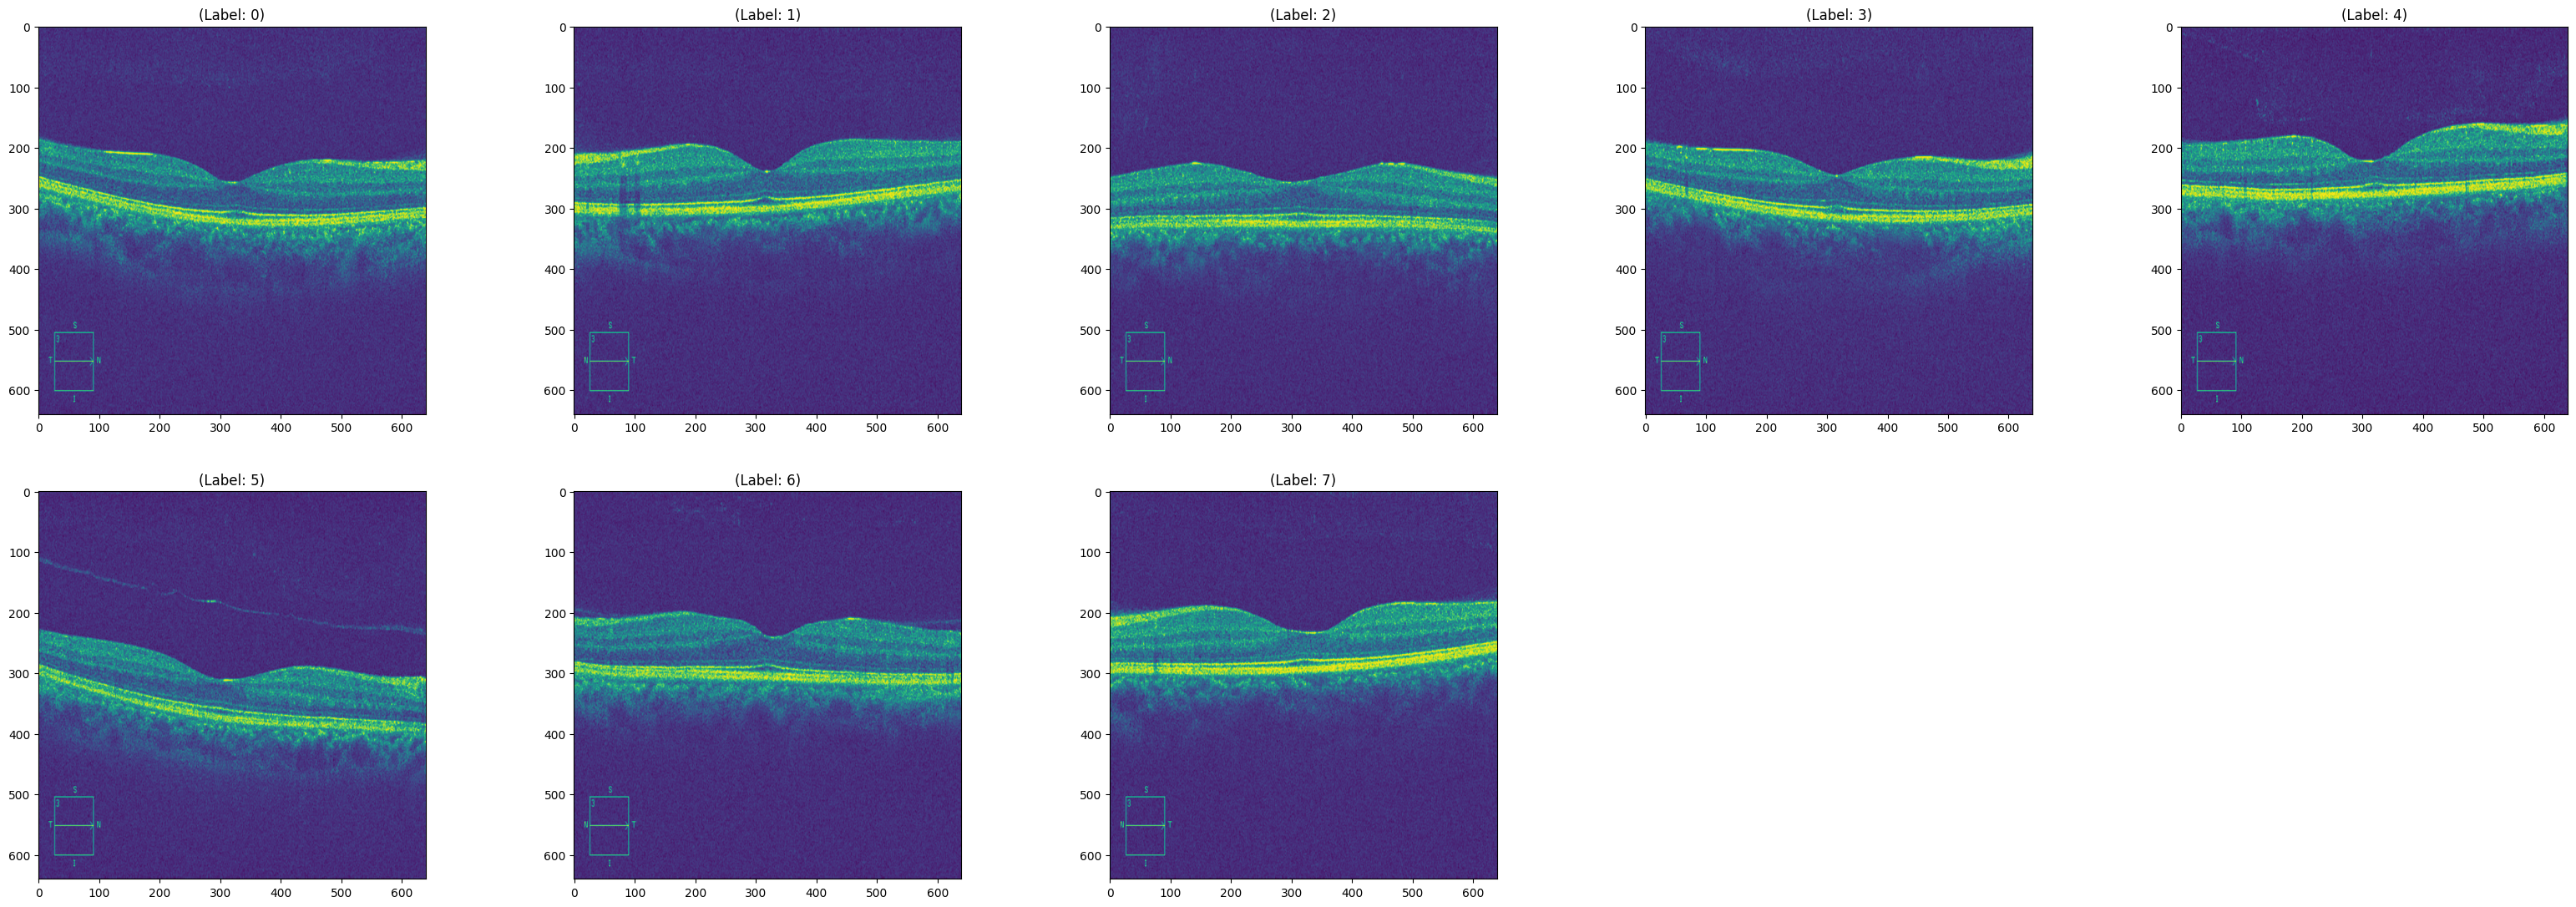

In [ ]:
plt.figure(figsize=(40,100))
for i in range(8):
    plt.subplot(14, 5, i+1)
    plt.imshow(train_images[i,:,:])
    plt.title("(Label: " + str(i) + ")")
plt.show()

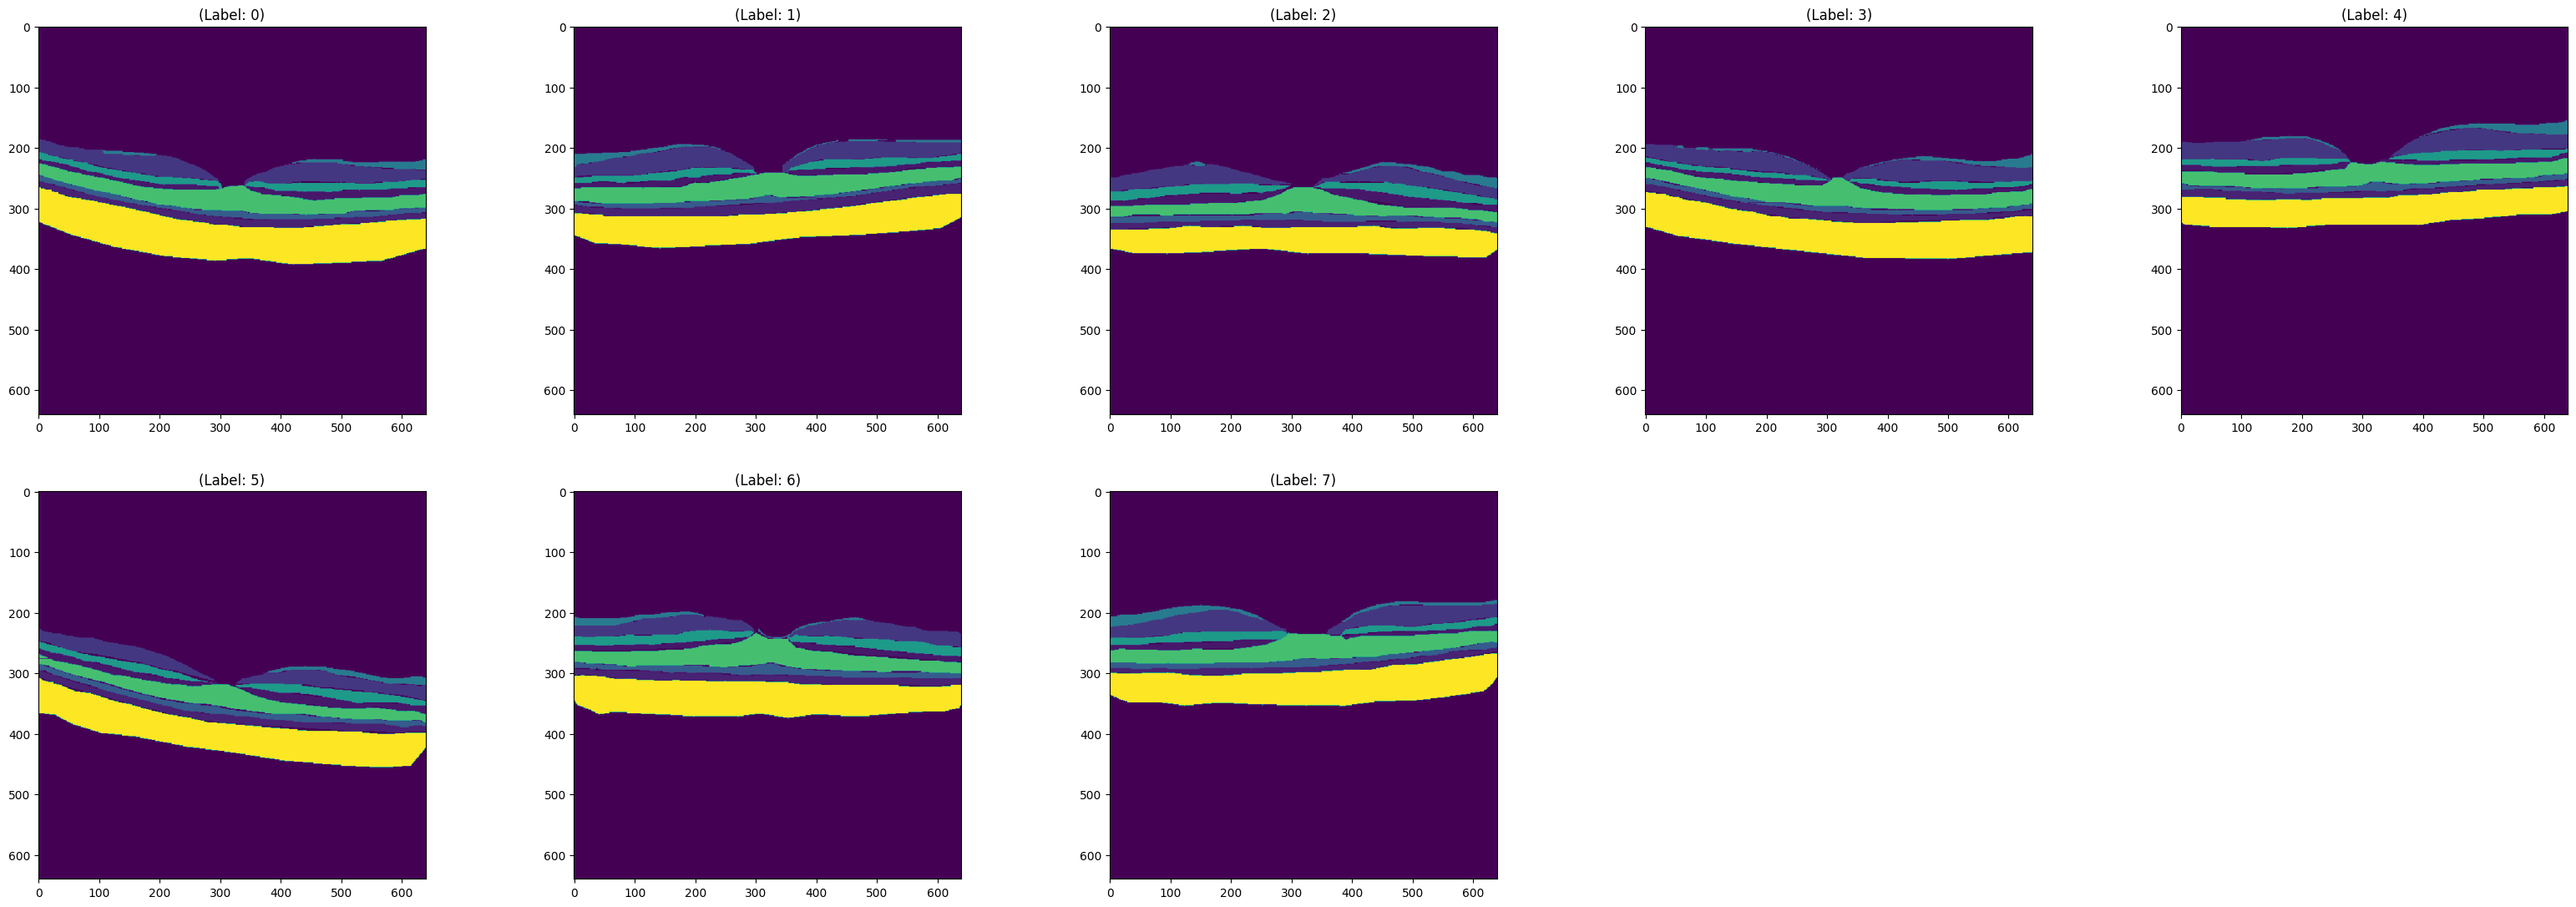

In [ ]:
plt.figure(figsize=(40,100))
for i in range(8):
    plt.subplot(14, 5, i+1)
    plt.imshow(train_masks[i,:,:])
    plt.title("(Label: " + str(i) + ")")
plt.show()

In [ ]:
#Encode labels
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
n, h, w = train_masks.shape
train_masks_reshaped = train_masks.reshape(-1,1)
train_masks_reshaped_encoded = labelencoder.fit_transform(train_masks_reshaped)
train_masks_encoded_original_shape = train_masks_reshaped_encoded.reshape(n, h, w)

np.unique(train_masks_encoded_original_shape)

train_images = np.expand_dims(train_images, axis=3)
train_images = normalize(train_images, axis=1)

train_masks_input = np.expand_dims(train_masks_encoded_original_shape, axis=3)


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_label.py:116: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:

#Create a subset of data for quick testing
#Picking 10% for testing and remaining for training
from sklearn.model_selection import train_test_split
X1, X_test, y1, y_test = train_test_split(train_images, train_masks_input, test_size = 0.10, random_state = 0)

#Further split training data t a smaller subset for quick testing of models
X_train, X_do_not_use, y_train, y_do_not_use = train_test_split(X1, y1, test_size = 0.2, random_state = 0)

print("Class values in the dataset are ... ", np.unique(y_train))  # 0 is the background/few unlabeled


Class values in the dataset are ...  [0 1 2 3 4 5 6 7 8]


In [ ]:
from keras.utils import to_categorical
train_masks_cat = to_categorical(y_train, num_classes=n_classes)
y_train_cat = train_masks_cat.reshape((y_train.shape[0], y_train.shape[1], y_train.shape[2], n_classes))



test_masks_cat = to_categorical(y_test, num_classes=n_classes)
y_test_cat = test_masks_cat.reshape((y_test.shape[0], y_test.shape[1], y_test.shape[2], n_classes))


IMG_HEIGHT = X_train.shape[1]
IMG_WIDTH  = X_train.shape[2]
IMG_CHANNELS = X_train.shape[3]

In [ ]:
from simple_unet import multi_unet_model

In [ ]:
def get_model():
    return multi_unet_model(n_classes=n_classes, IMG_HEIGHT=SIZE_Y, IMG_WIDTH=SIZE_X, IMG_CHANNELS=1)

model = get_model()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 640, 640, 1)]        0         []                            
                                                                                                  
 conv2d_38 (Conv2D)          (None, 640, 640, 16)         160       ['input_3[0][0]']             
                                                                                                  
 dropout_18 (Dropout)        (None, 640, 640, 16)         0         ['conv2d_38[0][0]']           
                                                                                                  
 conv2d_39 (Conv2D)          (None, 640, 640, 16)         2320      ['dropout_18[0][0]']          
                                                                                            

In [ ]:
def get_model():
    return multi_unet_model(n_classes=n_classes, IMG_HEIGHT=SIZE_Y, IMG_WIDTH=SIZE_X, IMG_CHANNELS=1)

model = get_model()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_4 (InputLayer)        [(None, 640, 640, 1)]        0         []                            
                                                                                                  
 conv2d_57 (Conv2D)          (None, 640, 640, 16)         160       ['input_4[0][0]']             
                                                                                                  
 dropout_27 (Dropout)        (None, 640, 640, 16)         0         ['conv2d_57[0][0]']           
                                                                                                  
 conv2d_58 (Conv2D)          (None, 640, 640, 16)         2320      ['dropout_27[0][0]']          
                                                                                            

In [ ]:

#If starting with pre-trained weights.
#model.load_weights('???.hdf5')

history = model.fit(X_train, y_train_cat,
                    batch_size = 16,
                    verbose=1,
                    epochs=200,
                    validation_data=(X_test, y_test_cat),
                    #class_weight=class_weights,
                    shuffle=False)


_, acc = model.evaluate(X_test, y_test_cat)
print("Accuracy is = ", (acc * 100.0), "%")

Epoch 1/200
1/1 [==============================] - 1s 869ms/step - loss: 0.7324 - accuracy: 0.7774 - val_loss: 0.6601 - val_accuracy: 0.7985
Epoch 2/200
1/1 [==============================] - 1s 604ms/step - loss: 0.6926 - accuracy: 0.7774 - val_loss: 0.6301 - val_accuracy: 0.7985
Epoch 3/200
1/1 [==============================] - 1s 656ms/step - loss: 0.6574 - accuracy: 0.7774 - val_loss: 0.5795 - val_accuracy: 0.7985
Epoch 4/200
1/1 [==============================] - 1s 630ms/step - loss: 0.6185 - accuracy: 0.7774 - val_loss: 0.5362 - val_accuracy: 0.7985
Epoch 5/200
1/1 [==============================] - 1s 615ms/step - loss: 0.5985 - accuracy: 0.7774 - val_loss: 0.5144 - val_accuracy: 0.7985
Epoch 6/200
1/1 [==============================] - 1s 625ms/step - loss: 0.5964 - accuracy: 0.7774 - val_loss: 0.5053 - val_accuracy: 0.7985
Epoch 7/200
1/1 [==============================] - 1s 617ms/step - loss: 0.5826 - accuracy: 0.7774 - val_loss: 0.5063 - val_accuracy: 0.7985
Epoch 8/200
1

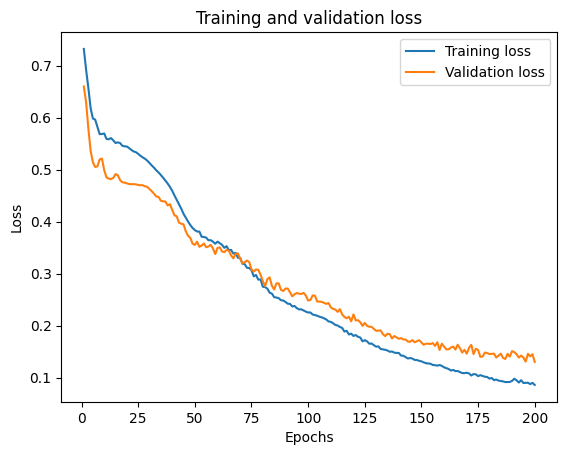

In [ ]:
#plot the training and validation accuracy and loss at each epoch
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:

acc = history.history['accuracy']
val_acc = history.history['accuracy']

plt.plot(epochs, acc 'y', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Training and validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


SyntaxError: invalid syntax (<ipython-input-61-a76e78399154>, line 4)

In [ ]:
from tensorflow.keras.models import load_model

# Load the model
model = load_model('/content/retina_segmentation_8_layer.hdf5')

# You can now use the model


In [ ]:
model=load_model('/content/retina_segmentation_8_layer.hdf5')

NameError: name 'load_model' is not defined

In [ ]:
y_pred=model.predict(X_test)
y_pred_argmax=np.argmax(y_pred, axis=3)

1/1 [==============================] - 0s 244ms/step


In [ ]:
#Using built in keras function
from keras.metrics import MeanIoU
IOU_keras = MeanIoU(num_classes=n_classes)
IOU_keras.update_state(y_test[:,:,:,0], y_pred_argmax)
print("Mean IoU =", IOU_keras.result().numpy())


Mean IoU = 0.73546493


IoU for class1 is:  0.99425924
IoU for class2 is:  0.8954325
IoU for class3 is:  0.9132778
IoU for class4 is:  0.9464762


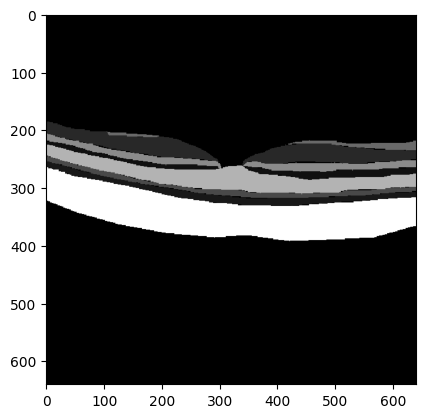

In [ ]:
## This is example of IOU of 4 class, if you need provide corresponding amount of class

values = np.array(IOU_keras.get_weights()).reshape(n_classes, n_classes)
class1_IoU = values[0,0]/(values[0,0] + values[0,1] + values[0,2] + values[0,3] + values[1,0]+ values[2,0]+ values[3,0])
class2_IoU = values[1,1]/(values[1,1] + values[1,0] + values[1,2] + values[1,3] + values[0,1]+ values[2,1]+ values[3,1])
class3_IoU = values[2,2]/(values[2,2] + values[2,0] + values[2,1] + values[2,3] + values[0,2]+ values[1,2]+ values[3,2])
class4_IoU = values[3,3]/(values[3,3] + values[3,0] + values[3,1] + values[3,2] + values[0,3]+ values[1,3]+ values[2,3])


print("IoU for class1 is: ", class1_IoU)
print("IoU for class2 is: ", class2_IoU)
print("IoU for class3 is: ", class3_IoU)
print("IoU for class4 is: ", class4_IoU)

plt.imshow(train_images[0, :,:,0], cmap='gray')
plt.imshow(train_masks[0], cmap='gray')

In [ ]:
# You can save your trained model by uncommenting below line

# model.save('retina_segmentation_8_layer_iter_3+20epochs.hdf5')

1/1 [==============================] - 0s 23ms/step


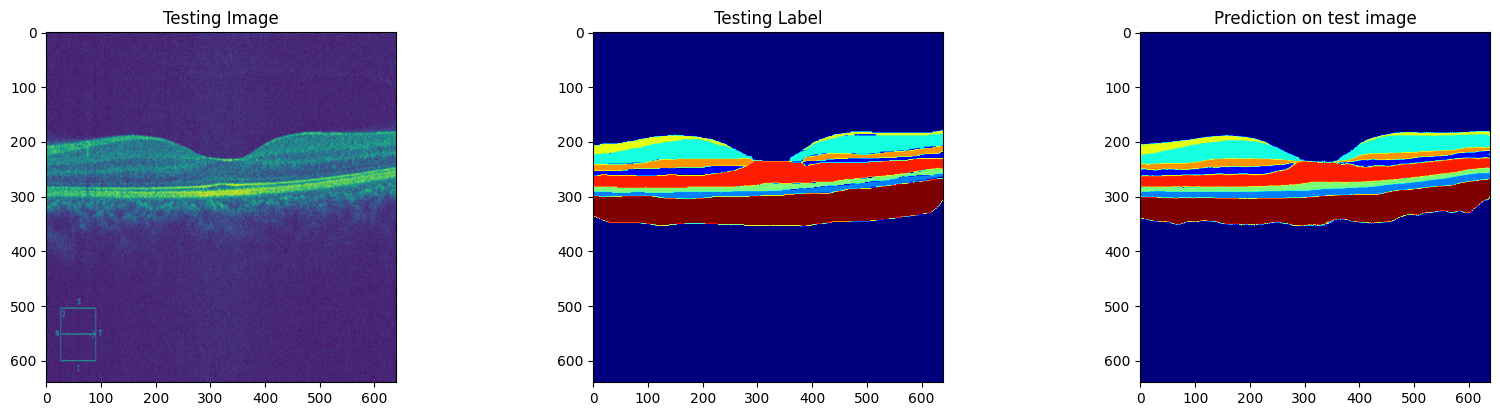

In [ ]:
test_img_number = 6
test_img = X_train[test_img_number]
ground_truth= y_train[test_img_number]
test_img_norm=test_img[:,:,0][:,:,None]
test_img_input=np.expand_dims(test_img_norm, 0)

prediction = (model.predict(test_img_input))
predicted_img = np.argmax(prediction, axis=3)[0,:,:]


plt.figure(figsize=(20, 10))
plt.subplot(231)
plt.title('Testing Image')
plt.imshow(test_img[:,:,0])
plt.subplot(232)
plt.title('Testing Label')
plt.imshow(ground_truth[:,:,0], cmap='jet')
plt.subplot(233)
plt.title('Prediction on test image')
plt.imshow(predicted_img, cmap='jet')
plt.show()

In [ ]:
#Capture training image info as a list
test_test = []

test_path = "/content/request_form_github/X"

for directory_path in glob.glob(test_path):
    for img_path in glob.glob(os.path.join(directory_path, "*.jpeg")):
        img = cv2.imread(img_path, 0)
        img = cv2.resize(img, (SIZE_Y, SIZE_X))
        test_test.append(img)
        print(img_path)

#Convert list to array for machine learning processing
test_test = np.array(test_test)

test_test = np.expand_dims(test_test, axis=3)
test_test = normalize(test_test, axis=1)

/content/request_form_github/X/33 OD - Copy.jpeg
/content/request_form_github/X/56 OS - Copy.jpeg
/content/request_form_github/X/31 OD - Copy.jpeg
/content/request_form_github/X/64 OD - Copy.jpeg
/content/request_form_github/X/22 OD - Copy.jpeg
/content/request_form_github/X/26 OD - Copy.jpeg
/content/request_form_github/X/34 OS - Copy.jpeg
/content/request_form_github/X/06 OS - Copy.jpeg
/content/request_form_github/X/108 OD - Copy.jpeg
/content/request_form_github/X/50 OD - Copy.jpeg


In [ ]:
test_test.shape

(10, 640, 640, 1)

1/1 [==============================] - 0s 23ms/step


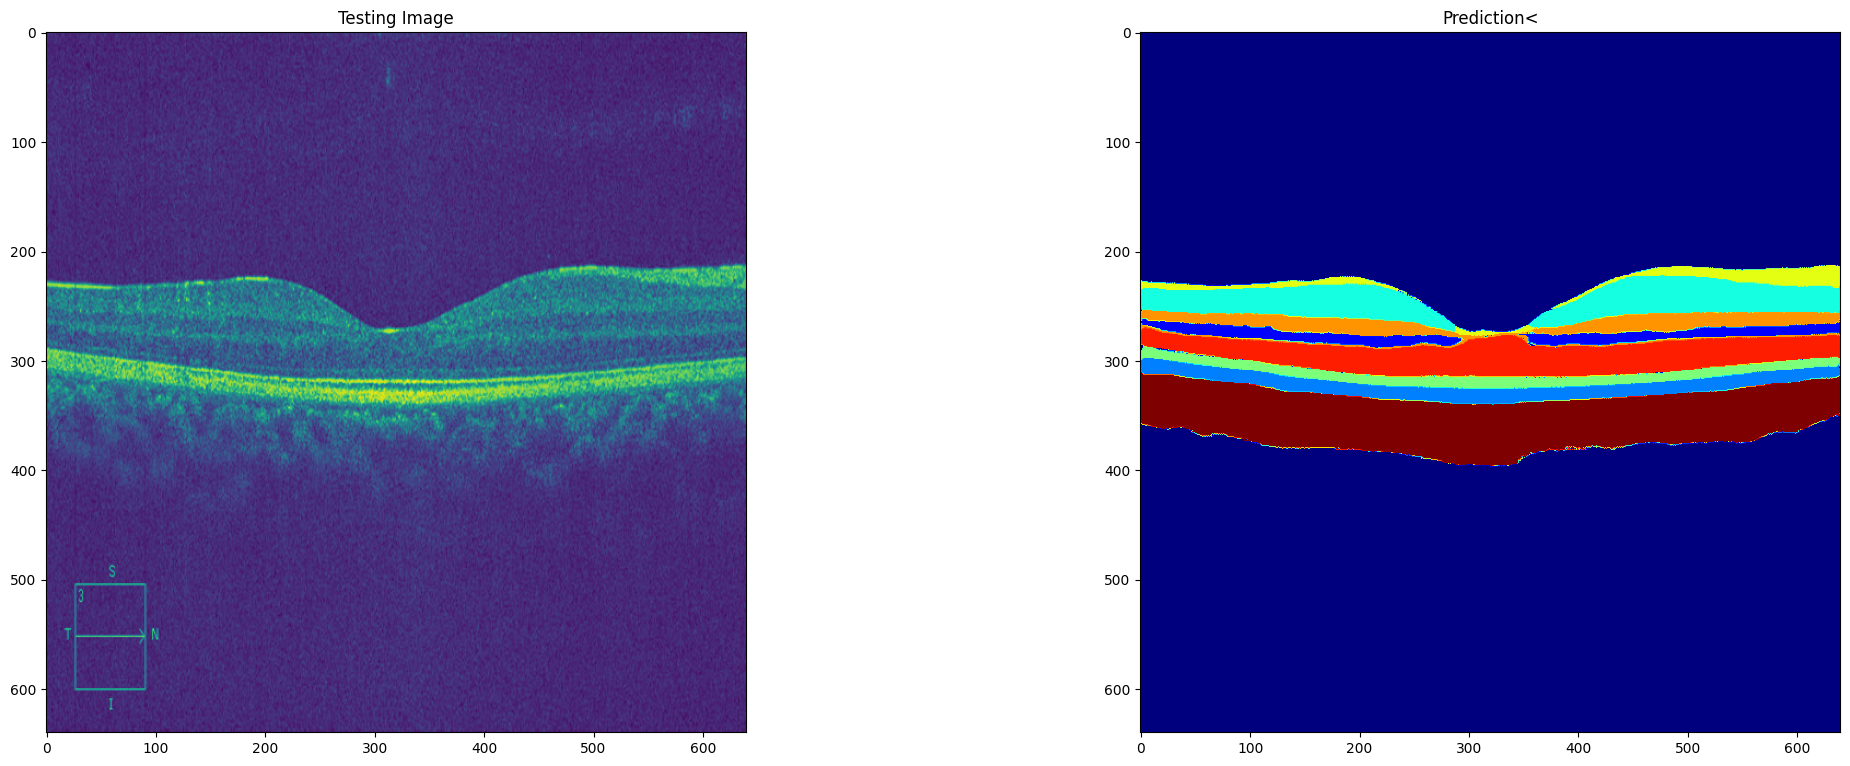

In [ ]:
test1 = test_test[9]
test_img_norm=test1[:,:,0][:,:,None]
test=np.expand_dims(test_img_norm, 0)

prediction = (model.predict(test))
predicted_img = np.argmax(prediction, axis=3)[0,:,:]

plt.figure(figsize=(40, 20))

plt.subplot(231)
plt.title('Testing Image')
plt.imshow(test1[:,:,0])

plt.subplot(232)
plt.title('Prediction<')
# plt.imshow(ground_truth[:,:,0], cmap='jet')
plt.imshow(predicted_img, cmap='jet')

# plt.imshow(prediction[0,:,:,7], cmap='jet')


In [ ]:
prediction.shape

(1, 640, 640, 9)

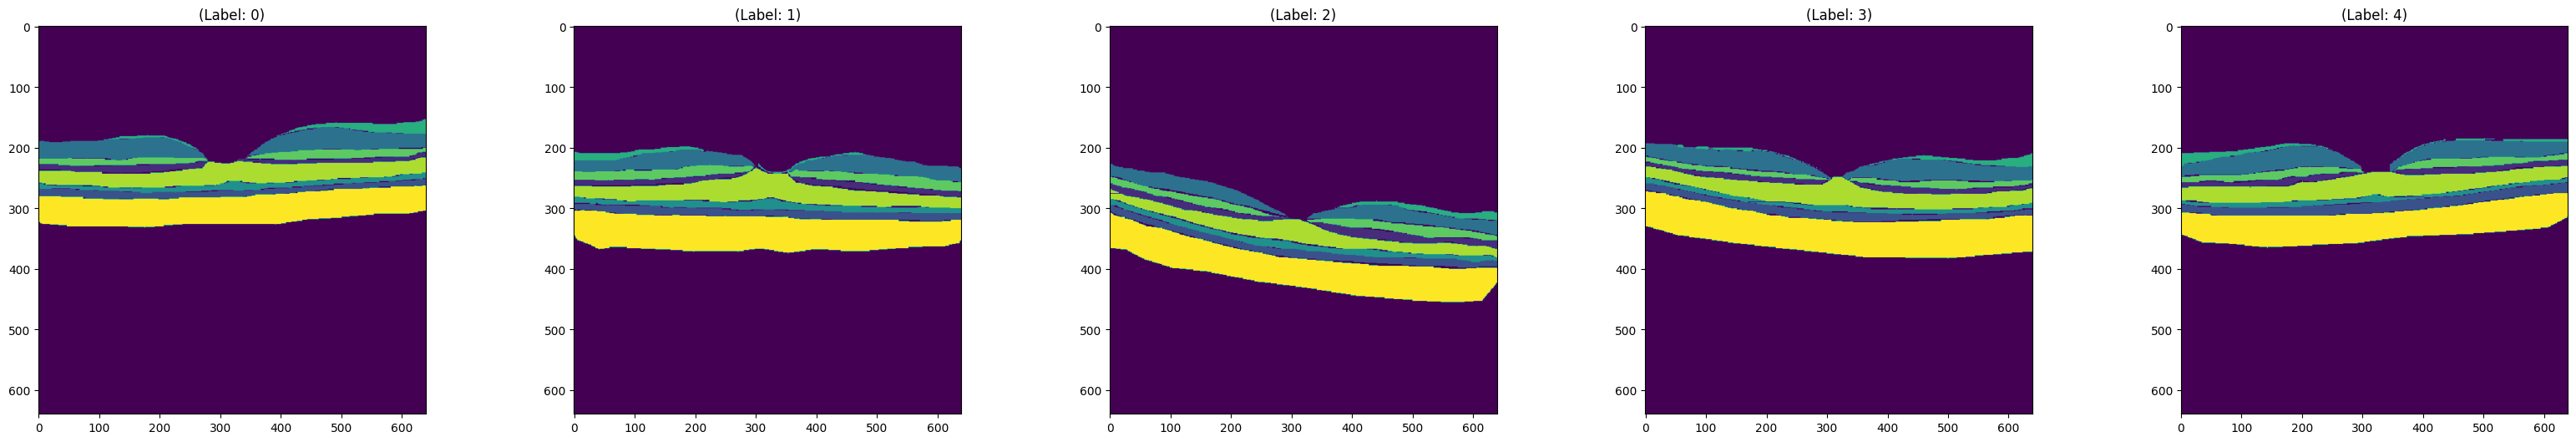

In [ ]:
plt.figure(figsize=(40,100))
# print("Оригинал изображений")
for i in range(5):
    plt.subplot(14, 5, i+1)
    plt.imshow(y_train[i,:,:])
    # curr_lbl = X_test[i]
    plt.title("(Label: " + str(i) + ")")
plt.show()

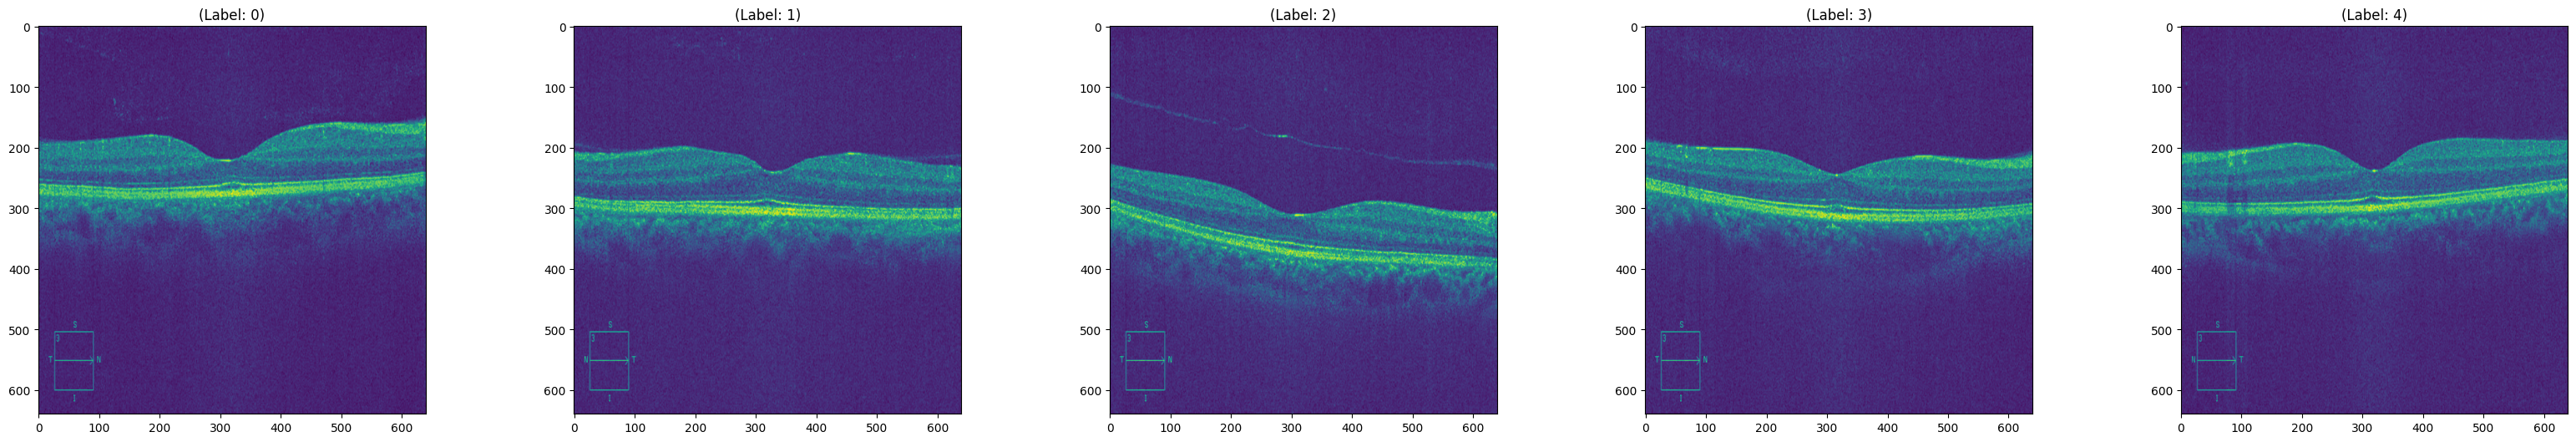

In [ ]:
plt.figure(figsize=(40,100))
# print("Оригинал изображений")
for i in range(5):
    plt.subplot(14, 5, i+1)
    plt.imshow(X_train[i,:,:])
    # curr_lbl = X_test[i]
    plt.title("(Label: " + str(i) + ")")
plt.show()

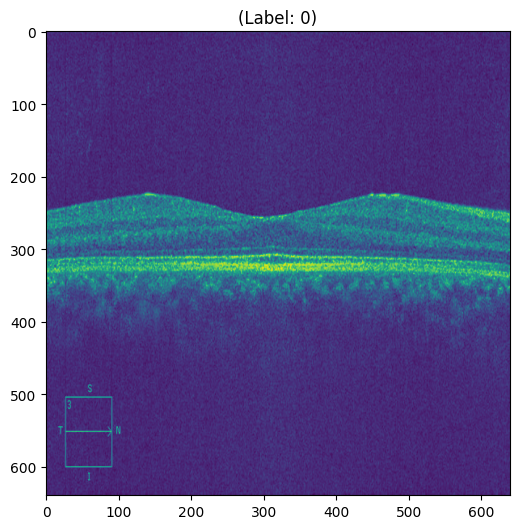

In [ ]:
plt.figure(figsize=(40,100))
# print("Оригинал изображений")
for i in range(1):
    plt.subplot(14, 5, i+1)
    plt.imshow(X_test[i,:,:])
    # curr_lbl = X_test[i]
    plt.title("(Label: " + str(i) + ")")
plt.show()

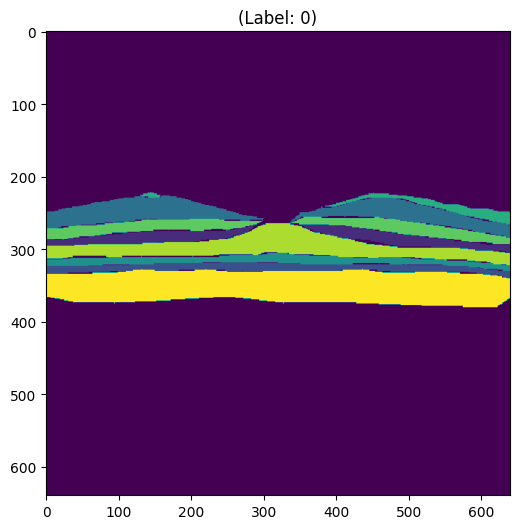

In [ ]:
plt.figure(figsize=(40,100))
# print("Оригинал изображений")
for i in range(1):
    plt.subplot(14, 5, i+1)
    plt.imshow(y_test[i,:,:])
    # curr_lbl = X_test[i]
    plt.title("(Label: " + str(i) + ")")
plt.show()